In [ ]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark
import builtins

from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import StackingClassifier   
from sklearn.model_selection import cross_val_score


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import split, explode
from pyspark.sql.functions import count, col
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, sum, hour
from pyspark.sql.functions import rank, dense_rank
from pyspark.sql.types import StringType, DateType
from pyspark.sql.types import TimestampType


In [10]:
spark = SparkSession.builder \
    .appName("MyApp") \
    .getOrCreate()

In [51]:
def norm(s): return s.astype(str).str.strip().str.lower()

def clean_categorical(df):
    df_x = df
    df_x["payment_method"] = norm(df_x["payment_method"]).replace({
    "paypall": "paypal", "pay pal": "paypal", "pay_pal": "paypal", "paypal": "paypal",
    " paypal": "paypal", "paypal ": "paypal",
    "debiit card": "debit card", "debit_card": "debit card", "debitcard": "debit card",
    " debit card": "debit card", "debit card ": "debit card",
    " apple pay": "apple pay", "apple_pay": "apple pay", "applepay": "apple pay",
    "gooogle pay": "google pay", "google_pay": "google pay", "googlepay": "google pay",
    " google pay": "google pay",
    "credt card": "credit card", "credit_card": "credit card", "creditcard": "credit card",
    " credit card": "credit card",
})

    df_x["device_type"] = norm(df_x["device_type"]).replace({
        "moblie": "mobile", " mobile": "mobile", "mobile ": "mobile",
        "tabelt": "tablet", " tablet": "tablet", "tablet_device": "tablet", "tab let": "tablet",
        "desktp": "desktop", " desktop": "desktop", "desktop_pc": "desktop", "desk top": "desktop",
    })

    df_x["location"] = (
        df_x["location"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "canada": "canada",
            "canadaa": "canada",
            "ca": "canada",

            "germany": "germany",

            "india": "india",
            "indai": "india",
            "in": "india",

            "australia": "australia",
            "austraila": "australia",
            "au": "australia",

            "uk": "uk",
            "u.k.": "uk",
            "united kingdom": "uk",
            "untied kingdom": "uk",

            "usa": "usa",
            "us": "usa",
            "u.s.a.": "usa",

            "unknown region": "Other",
            "atlantis": "atlantis",
            "mars colony": "mars"
        })
    )

    df_x["merchant_category"] = norm(df_x["merchant_category"]).replace({
        "fashoin": "fashion", "fashon": "fashion",
        "groceriez": "groceries", "grocery": "groceries",
        "electornics": "electronics", "electronic": "electronics",
        "restaraunts": "restaurants",
        "travels": "travel",
        "gameing": "gaming",
    })
    return df_x


In [ ]:

def preprocess_dataframe(df):
    df_x = df
    if("transaction_timestamp" in df.columns):
        df_x = df.drop(columns=["transaction_id", "customer_id", "transaction_timestamp",
                        ])
    bool_map = {
    "true": 1, "yes": 1, "y": 1, "1":1,
    "false": 0, "no": 0, "n": 0, "0":0,
}
    for col in ["is_international", "unusual_amount_flag", "multiple_transactions_short_time", "high_risk_device_flag"]:
        df_x[col] = norm(df_x[col]).map(bool_map).astype("Int32")
    df_x["transaction_amount"] = pd.to_numeric(df_x["transaction_amount"], errors="coerce")
    df_x["transaction_frequency_24h"] = norm(df_x["transaction_frequency_24h"]).replace({"many": "200"})
    df_x["transaction_frequency_24h"] = pd.to_numeric(df_x["transaction_frequency_24h"], errors="coerce").astype("Int32")
    df_x["avg_transaction_amount_7d"] = pd.to_numeric(df_x["avg_transaction_amount_7d"], errors="coerce")
    df_x["failed_transaction_count_24h"] = pd.to_numeric(df_x["failed_transaction_count_24h"], errors="coerce").astype("Int32")
    df_x["account_age_days"] = pd.to_numeric(df_x["account_age_days"], errors="coerce").astype("Int32")
    num_not_bool = [
    "transaction_amount",
    "transaction_frequency_24h",
    "avg_transaction_amount_7d",
    "failed_transaction_count_24h",
    "account_age_days",
    'location_hist',
    'merchant_hist',
    'fruad_hist',
    'avg_time'
    
]
    
    cat_cols = df_x.select_dtypes(include=["object", "category"]).columns
    
    bool_cols = [x for x in df_x.columns if (x not in num_not_bool and x != 'label' and x not in cat_cols)] 
    df_x = clean_categorical(df_x)

    pipe_bool = Pipeline(steps=[
        ('impute', KNNImputer(n_neighbors=5))
    ])
    pipe_cat = Pipeline(steps=[
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ])
    pipe_num = Pipeline(steps=[
        ("impute", KNNImputer(n_neighbors=5)),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        
    ])
    colTrans = ColumnTransformer(transformers=[
        ("num", pipe_num, num_not_bool),
        ("bools", pipe_bool, bool_cols),
        ("cat", pipe_cat, cat_cols)
    ], remainder='passthrough')
    df_x = colTrans.fit_transform(df_x)
    feature_names = colTrans.get_feature_names_out()
    df_x_clean = pd.DataFrame(data=df_x, columns=feature_names)
    df_x_clean = df_x_clean.astype('float64')
    df_x_clean["amount_ratio_7d"] = (df_x_clean["num__transaction_amount"] / (df_x_clean["num__avg_transaction_amount_7d"] + 1))

    df_x_clean["amount_per_account_day"] = (df_x_clean["num__transaction_amount"] / (df_x_clean["num__account_age_days"] + 1))

    df_x_clean["international_large_amount"] = (df_x_clean["bools__is_international"] * df_x_clean["amount_ratio_7d"])
    return df_x_clean


In [13]:
file_location = "./train.xlsx"

In [53]:
df_base = pd.read_excel(file_location)
df = df_base
df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'])
df = df.sort_values("transaction_timestamp")


In [ ]:
bool_map = {
    "true": 1, "yes": 1, "y": 1, "1":1,
    "false": 0, "no": 0, "n": 0, "0":0,
}
hist = {}
df_hist = clean_categorical(df)
df_hist['location_hist'] = 0
df_hist['merchant_hist'] = 0
df_hist['fruad_hist'] = 0
df_hist['avg_time'] = 0
for index, row in df_hist.iterrows():
    loc = row['location']
    mer = row['merchant_category']
    fr = row['label']
    id = row['customer_id']
    inter = row['is_international']
    
    if(inter != 1 and inter != 0):
        inter = inter.lower().strip()
    if(not inter in bool_map):
        inter = 0
    else:
        inter = bool_map[inter]
    dt = pd.to_datetime(row['transaction_timestamp'])
    if(not id in hist):
        hist[id] = {'loc':[], 'mer':[], 'fr':[], 'last':'', 'time':[]}
    
    df_hist.iat[index, df_hist.columns.get_loc('location_hist')] = len(hist[id]['loc'])
    df_hist.iat[index, df_hist.columns.get_loc('merchant_hist')] = len(hist[id]['mer'])
    df_hist.iat[index, df_hist.columns.get_loc('fruad_hist')] = builtins.sum(hist[id]['fr'])
    
    df_hist.iat[index, df_hist.columns.get_loc('avg_time')] = np.sum(hist[id]['time'])
    
    if(not loc in hist[id]['loc']):
        hist[id]['loc'].append(loc)
    if(not mer in hist[id]['mer']):
        hist[id]['mer'].append(mer)
        
    hist[id]['fr'].append(int(fr))
    hist[id]['time'].append(inter)
    

  
    

In [55]:
df_hist.value_counts('merchant_hist')

merchant_hist
0    27937
1    25113
2    16477
3     7687
4     2316
5      425
6       43
7        2
Name: count, dtype: int64

In [56]:
df = df_hist
df_hist.value_counts('location_hist')


location_hist
0    27937
1    25014
2    16693
3     7578
4     2356
5      380
6       40
7        2
Name: count, dtype: int64

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   transaction_id                    80000 non-null  str           
 1   customer_id                       80000 non-null  str           
 2   transaction_timestamp             80000 non-null  datetime64[us]
 3   transaction_amount                78164 non-null  object        
 4   payment_method                    79190 non-null  str           
 5   device_type                       79174 non-null  str           
 6   location                          79184 non-null  str           
 7   merchant_category                 79193 non-null  str           
 8   is_international                  80000 non-null  object        
 9   transaction_frequency_24h         78608 non-null  object        
 10  avg_transaction_amount_7d         78126 non-null  object 

In [ ]:
df_drop = df.drop(columns=["transaction_id", "customer_id", "transaction_timestamp",
                        ])


X = preprocess_dataframe(df_drop)
Y = X['remainder__label']
X = X.drop('remainder__label', axis=1)


/tmp/ipykernel_52988/2938715145.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_x.select_dtypes(include=["object", "category"]).columns


<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 98 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   num__transaction_amount                                      80000 non-null  float64
 1   num__transaction_frequency_24h                               80000 non-null  float64
 2   num__avg_transaction_amount_7d                               80000 non-null  float64
 3   num__failed_transaction_count_24h                            80000 non-null  float64
 4   num__account_age_days                                        80000 non-null  float64
 5   num__location_hist                                           80000 non-null  float64
 6   num__merchant_hist                                           80000 non-null  float64
 7   num__fruad_hist                                              80000 non-null  float64
 8

In [ ]:
X.head()
print(X.info())
print('------------')
print(Y.info())

ValueError: supplied range of [-inf, inf] is not finite

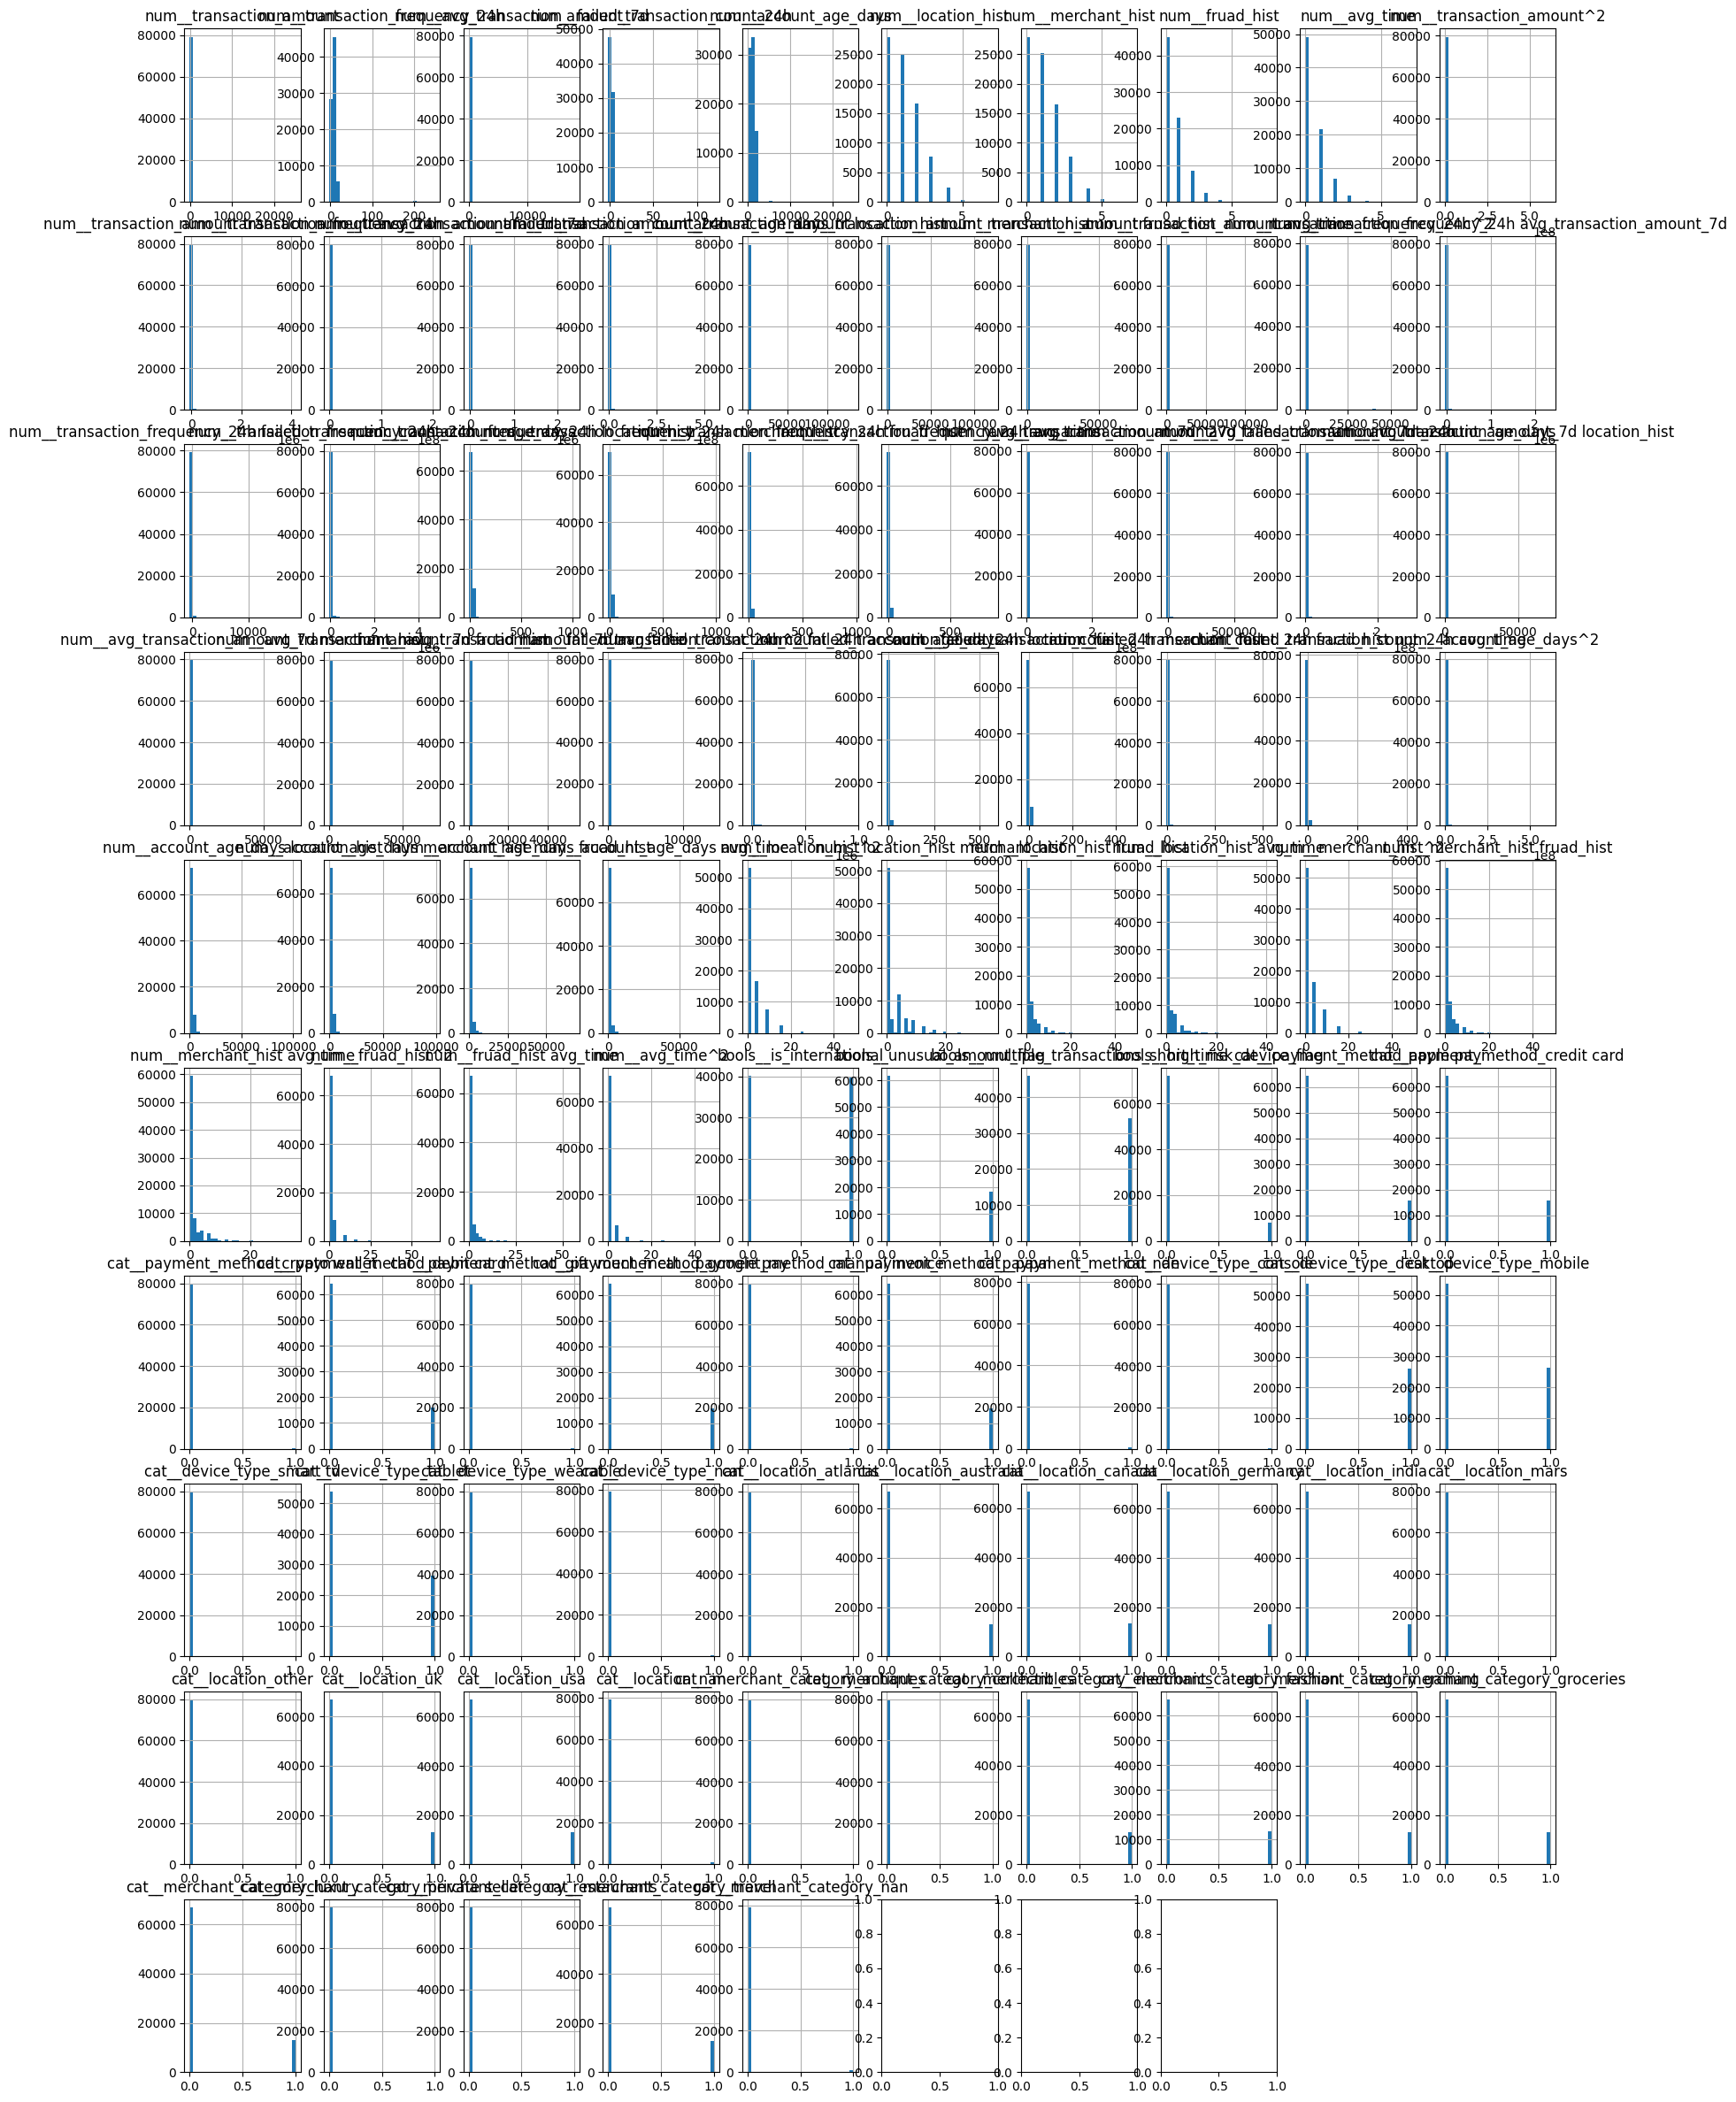

In [58]:
X.hist(bins=30, figsize=(20, 30))

In [21]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 98 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   num__transaction_amount                                      80000 non-null  float64
 1   num__transaction_frequency_24h                               80000 non-null  float64
 2   num__avg_transaction_amount_7d                               80000 non-null  float64
 3   num__failed_transaction_count_24h                            80000 non-null  float64
 4   num__account_age_days                                        80000 non-null  float64
 5   num__location_hist                                           80000 non-null  float64
 6   num__merchant_hist                                           80000 non-null  float64
 7   num__fruad_hist                                              80000 non-null  float64
 8

In [22]:
X.head()

,num__transaction_amount,num__transaction_frequency_24h,num__avg_transaction_amount_7d,num__failed_transaction_count_24h,num__account_age_days,num__location_hist,num__merchant_hist,num__fruad_hist,num__avg_time,num__transaction_amount^2,num__transaction_amount transaction_frequency_24h,num__transaction_amount avg_transaction_amount_7d,num__transaction_amount failed_transaction_count_24h,num__transaction_amount account_age_days,num__transaction_amount location_hist,num__transaction_amount merchant_hist,num__transaction_amount fruad_hist,num__transaction_amount avg_time,num__transaction_frequency_24h^2,num__transaction_frequency_24h avg_transaction_amount_7d,num__transaction_frequency_24h failed_transaction_count_24h,num__transaction_frequency_24h account_age_days,num__transaction_frequency_24h location_hist,num__transaction_frequency_24h merchant_hist,num__transaction_frequency_24h fruad_hist,num__transaction_frequency_24h avg_time,num__avg_transaction_amount_7d^2,num__avg_transaction_amount_7d failed_transaction_count_24h,num__avg_transaction_amount_7d account_age_days,num__avg_transaction_amount_7d location_hist,num__avg_transaction_amount_7d merchant_hist,num__avg_transaction_amount_7d fruad_hist,num__avg_transaction_amount_7d avg_time,num__failed_transaction_count_24h^2,num__failed_transaction_count_24h account_age_days,num__failed_transaction_count_24h location_hist,num__failed_transaction_count_24h merchant_hist,num__failed_transaction_count_24h fruad_hist,num__failed_transaction_count_24h avg_time,num__account_age_days^2,...,cat__payment_method_apple pay,cat__payment_method_credit card,cat__payment_method_crypto wallet,cat__payment_method_debit card,cat__payment_method_gift voucher,cat__payment_method_google pay,cat__payment_method_manual invoice,cat__payment_method_paypal,cat__payment_method_nan,cat__device_type_console,cat__device_type_desktop,cat__device_type_mobile,cat__device_type_smart tv,cat__device_type_tablet,cat__device_type_wearable,cat__device_type_nan,cat__location_atlantis,cat__location_australia,cat__location_canada,cat__location_germany,cat__location_india,cat__location_mars,cat__location_other,cat__location_uk,cat__location_usa,cat__location_nan,cat__merchant_category_antiques,cat__merchant_category_collectibles,cat__merchant_category_electronics,cat__merchant_category_fashion,cat__merchant_category_gaming,cat__merchant_category_groceries,cat__merchant_category_luxury,cat__merchant_category_private seller,cat__merchant_category_restaurants,cat__merchant_category_travel,cat__merchant_category_nan,amount_ratio_7d,amount_per_account_day,international_large_amount
0,0.151099,0.807774,0.099730,0.478968,1.079185,0.0,0.0,0.0,0.0,1.661665e-03,0.142688,0.020120,0.053454,0.113481,0.0,0.0,0.0,0.0,0.056600,0.085636,0.432422,0.612160,0.0,0.0,0.0,0.0,0.000718,0.058664,0.080357,0.0,0.0,0.0,0.0,0.015574,0.496212,0.0,0.0,0.0,0.0,0.087655,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.137396,0.072672,0.137396
1,0.238445,0.519284,0.100275,0.000000,1.211653,0.0,0.0,0.0,0.0,4.138079e-03,0.144753,0.031925,0.000000,0.201063,0.0,0.0,0.0,0.0,0.023391,0.055353,0.000000,0.441837,0.0,0.0,0.0,0.0,0.000725,0.000000,0.090714,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.110495,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.216714,0.107813,0.000000
2,0.101550,0.807774,0.076930,0.000000,0.761693,0.0,0.0,0.0,0.0,7.505606e-04,0.095897,0.010431,0.000000,0.053830,0.0,0.0,0.0,0.0,0.056600,0.066058,0.000000,0.432065,0.0,0.0,0.0,0.0,0.000427,0.000000,0.043750,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.043666,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.094296,0.057644,0.000000
3,0.000469,0.346189,0.096485,0.4789

In [23]:
print(Y.info())
correlations = X.corrwith(Y)
correlations = correlations.sort_values(key=abs, ascending=False)
print(correlations)

<class 'pandas.Series'>
RangeIndex: 80000 entries, 0 to 79999
Series name: remainder__label
Non-Null Count  Dtype  
--------------  -----  
80000 non-null  float64
dtypes: float64(1)
memory usage: 625.1 KB
None
bools__is_international                    0.424124
bools__multiple_transactions_short_time    0.346364
bools__unusual_amount_flag                 0.329361
bools__high_risk_device_flag               0.128332
num__transaction_frequency_24h             0.072133
                                             ...   
cat__payment_method_gift voucher           0.000324
cat__merchant_category_nan                 0.000286
cat__location_india                       -0.000246
cat__location_atlantis                    -0.000193
num__account_age_days                      0.000157
Length: 98, dtype: float64


In [59]:
X['label'] = Y
print(X.corr(numeric_only=True)['label'].sort_values(ascending=False))
X = X.drop('label', axis=1)

label                                      1.000000
bools__is_international                    0.424124
bools__multiple_transactions_short_time    0.346364
bools__unusual_amount_flag                 0.329361
bools__high_risk_device_flag               0.128332
                                             ...   
num__location_hist^2                      -0.010319
num__location_hist                        -0.011159
num__avg_transaction_amount_7d            -0.012452
cat__device_type_tablet                   -0.022867
cat__device_type_desktop                  -0.037007
Name: label, Length: 99, dtype: float64


In [ ]:
scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "accuracy": "accuracy"
}

In [60]:
from sklearn.model_selection import cross_val_score
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=500,              
    depth=10,                  
    learning_rate=0.02,           
    l2_leaf_reg=0.1,              
    subsample=0.7,                
    random_seed=42,
    verbose=0,      
    auto_class_weights='Balanced',
    leaf_estimation_method='Newton',
    od_type='Iter',             
    od_wait=50                    
)

catboost_scores = cross_val_score(
    catboost_model,
    X,
    Y,
    cv=5,
    scoring="f1"
)

print("CatBoost ROC-AUC:", catboost_scores.mean())
print(catboost_scores)

CatBoost ROC-AUC: 0.7930660657047038
[0.79765005 0.79355353 0.79337316 0.7901718  0.79058179]


/home/sami/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/sami/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/sami/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/sami/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/sami/.local/lib/python3.12/site-packages/p

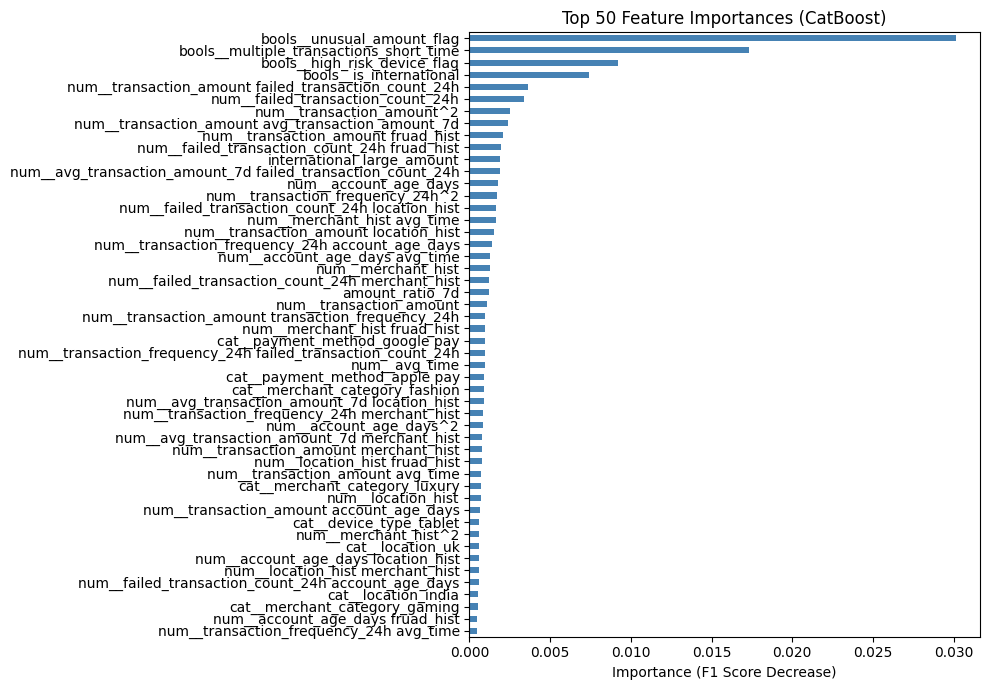

In [61]:
X_train, X_val_fi, y_train, y_val_fi = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)
catboost_model.fit(X_train, y_train)

result = permutation_importance(
    catboost_model, X_val_fi, y_val_fi, 
    n_repeats=5, random_state=42, n_jobs=-1
)

fi = pd.Series(result.importances_mean, index=X.columns)
fi_sorted = fi.sort_values(ascending=False).head(50)

fig, ax = plt.subplots(figsize=(10, 7))
fi_sorted.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 50 Feature Importances (CatBoost)')
ax.set_xlabel('Importance (F1 Score Decrease)')
plt.tight_layout()
plt.show()

In [63]:
k = 35
selected_features = fi_sorted.head(k).index.tolist()
X_reduced = X[selected_features]
X_base = X.copy()
X = X_reduced.copy()
print(X_reduced.info())

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 35 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   bools__unusual_amount_flag                                   80000 non-null  float64
 1   bools__multiple_transactions_short_time                      80000 non-null  float64
 2   bools__high_risk_device_flag                                 80000 non-null  float64
 3   bools__is_international                                      80000 non-null  float64
 4   num__transaction_amount failed_transaction_count_24h         80000 non-null  float64
 5   num__failed_transaction_count_24h                            80000 non-null  float64
 6   num__transaction_amount^2                                    80000 non-null  float64
 7   num__transaction_amount avg_transaction_amount_7d            80000 non-null  float64
 8

In [ ]:
base_params = {
    'iterations': 100,
    'depth': 10,
    'learning_rate': 0.02,
    'l2_leaf_reg': 0.1,
    
    'verbose': 0,
    'auto_class_weights': 'Balanced',
    'leaf_estimation_method': 'Newton',
    'od_type': 'Iter',
    'od_wait': 50
}


varied_params = [
    {'depth': 8,  'learning_rate': 0.03, 'l2_leaf_reg': 0.5,  'random_seed': 42},
    {'depth': 9,  'learning_rate': 0.025, 'l2_leaf_reg': 0.5, 'random_seed': 43},
    {'depth': 10, 'learning_rate': 0.02,  'l2_leaf_reg': 0.1,  'random_seed': 44},
    {'depth': 10, 'learning_rate': 0.02,  'l2_leaf_reg': 0.5,  'random_seed': 45},
    {'depth': 11, 'learning_rate': 0.015, 'l2_leaf_reg': 1.0,  'random_seed': 46},
    {'depth': 11, 'learning_rate': 0.015, 'l2_leaf_reg': 2.0,  'random_seed': 47},
    {'depth': 12, 'learning_rate': 0.01,  'l2_leaf_reg': 1.0,  'random_seed': 48},
    {'depth': 12, 'learning_rate': 0.01,  'l2_leaf_reg': 3.0,  'random_seed': 49},
    {'depth': 9,  'learning_rate': 0.025, 'l2_leaf_reg': 0.1,  'random_seed': 50},
    {'depth': 8,  'learning_rate': 0.03,  'l2_leaf_reg': 0.1,  'random_seed': 51},
    {'depth': 10, 'learning_rate': 0.025, 'l2_leaf_reg': 1.0,  'random_seed': 52},
]

estimators = []
for i, param in enumerate(varied_params):
    model_params = {**base_params, **param}
    model = CatBoostClassifier(**model_params)
    estimators.append((f'catboost_{i}', model))


ensemble = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=5,                        
    stack_method='predict_proba', 
    verbose=0
)


catboost_scores = cross_val_score(
    ensemble,
    X,
    Y,
    cv=2,
    scoring="f1"
)
print("CatBoost Stacking F1:", catboost_scores.mean())
print(catboost_scores)

CatBoost Stacking F1: 0.7967675180391112
[0.79713547 0.79639957]


In [64]:
df_test = pd.read_excel('./student_test.xlsx')
df_test.info()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   id                                20000 non-null  int64 
 1   transaction_id                    20000 non-null  str   
 2   customer_id                       20000 non-null  str   
 3   transaction_timestamp             20000 non-null  str   
 4   transaction_amount                19525 non-null  object
 5   payment_method                    19810 non-null  str   
 6   device_type                       19826 non-null  str   
 7   location                          19816 non-null  str   
 8   merchant_category                 19807 non-null  str   
 9   is_international                  20000 non-null  object
 10  transaction_frequency_24h         19641 non-null  object
 11  avg_transaction_amount_7d         19548 non-null  object
 12  failed_transaction_count_24h 

In [65]:
df_test = clean_categorical(df_test)
df_test['location_hist'] = 0
df_test['merchant_hist'] = 0
df_test['fruad_hist'] = 0
df_test['avg_time'] = 0
count = 0
for index, row in df_test.iterrows():
    loc = row['location']
    mer = row['merchant_category']
    
    id = row['customer_id']
    
    if id in hist:
        df_test.iat[index, df_hist.columns.get_loc('location_hist')] = len(hist[id]['loc'])
        df_test.iat[index, df_hist.columns.get_loc('merchant_hist')] = len(hist[id]['mer'])
        df_test.iat[index, df_hist.columns.get_loc('fruad_hist')] = builtins.sum(hist[id]['fr'])
        df_test.iat[index, df_hist.columns.get_loc('avg_time')] = np.sum(hist[id]['time'])
        
        
        count += 1
print(count)

18599


In [66]:
ID = df_test['id'].values
df_test = df_test.drop('id', axis=1)
df_test = preprocess_dataframe(df_test)

df_test.info()

/tmp/ipykernel_52988/2938715145.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_x.select_dtypes(include=["object", "category"]).columns


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 98 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   num__transaction_amount                                      20000 non-null  float64
 1   num__transaction_frequency_24h                               20000 non-null  float64
 2   num__avg_transaction_amount_7d                               20000 non-null  float64
 3   num__failed_transaction_count_24h                            20000 non-null  float64
 4   num__account_age_days                                        20000 non-null  float64
 5   num__location_hist                                           20000 non-null  float64
 6   num__merchant_hist                                           20000 non-null  float64
 7   num__fruad_hist                                              20000 non-null  float64
 8

In [67]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 35 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   bools__unusual_amount_flag                                   80000 non-null  float64
 1   bools__multiple_transactions_short_time                      80000 non-null  float64
 2   bools__high_risk_device_flag                                 80000 non-null  float64
 3   bools__is_international                                      80000 non-null  float64
 4   num__transaction_amount failed_transaction_count_24h         80000 non-null  float64
 5   num__failed_transaction_count_24h                            80000 non-null  float64
 6   num__transaction_amount^2                                    80000 non-null  float64
 7   num__transaction_amount avg_transaction_amount_7d            80000 non-null  float64
 8

In [ ]:
base_params = {
    'iterations': 100,
    'depth': 10,
    'learning_rate': 0.02,
    'l2_leaf_reg': 0.1,
    
    'verbose': 0,
    'auto_class_weights': 'Balanced',
    'leaf_estimation_method': 'Newton',
    'od_type': 'Iter',
    'od_wait': 50
}


varied_params = [
    {'depth': 8,  'learning_rate': 0.03, 'l2_leaf_reg': 0.5,  'random_seed': 42},
    {'depth': 9,  'learning_rate': 0.025, 'l2_leaf_reg': 0.5, 'random_seed': 43},
    {'depth': 10, 'learning_rate': 0.02,  'l2_leaf_reg': 0.1,  'random_seed': 44},
    {'depth': 10, 'learning_rate': 0.02,  'l2_leaf_reg': 0.5,  'random_seed': 45},
    {'depth': 11, 'learning_rate': 0.015, 'l2_leaf_reg': 1.0,  'random_seed': 46},
    {'depth': 11, 'learning_rate': 0.015, 'l2_leaf_reg': 2.0,  'random_seed': 47},
    {'depth': 12, 'learning_rate': 0.01,  'l2_leaf_reg': 1.0,  'random_seed': 48},
    {'depth': 12, 'learning_rate': 0.01,  'l2_leaf_reg': 3.0,  'random_seed': 49},
    {'depth': 9,  'learning_rate': 0.025, 'l2_leaf_reg': 0.1,  'random_seed': 50},
    {'depth': 8,  'learning_rate': 0.03,  'l2_leaf_reg': 0.1,  'random_seed': 51},
    {'depth': 10, 'learning_rate': 0.025, 'l2_leaf_reg': 1.0,  'random_seed': 52},
]

estimators = []
for i, param in enumerate(varied_params):
   
    model_params = {**base_params, **param}
    
    model = CatBoostClassifier(**model_params)
    estimators.append((f'catboost_{i}', model))


ensemble = VotingClassifier(
    estimators=estimators,
    voting='soft'   
)


ensemble.fit(X, Y)


res = ensemble.predict(df_test)


print(len(res))

20000


In [69]:
df_test = df_test[selected_features]

In [70]:
res = ensemble.predict(df_test)  
probs = ensemble.predict_proba(df_test)
print(len(res))

20000


In [71]:

res = res.astype(int)
print(res)
data = {
    "id": ID,
    "label": res
}

df = pd.DataFrame(data)
df.to_csv("submission.csv", index=False)


[0 0 0 ... 1 1 1]
